Imports

In [ ]:
import notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from platform import python_version
import xgboost as xgb
import graphviz
import sklearn
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE


print(f"python: v {python_version()}")
print(f"Jupyter Notebook: v {notebook.__version__}")
print(f"numpy: v {np.__version__}")
print(f"pandas: v {pd.__version__}")
print(f"seaborn: v {sns.__version__}")
print(f"graphviz: v {graphviz.__version__}")
print(f"matplotlib: v {matplotlib.__version__}")
print(f"sklearn: v {sklearn.__version__}")
print(f"XGBoost: v {xgb.__version__}")

python: v 3.10.12
Jupyter Notebook: v 7.4.7
numpy: v 1.25.2
pandas: v 2.3.3
seaborn: v 0.13.2
graphviz: v 0.21
matplotlib: v 3.7.2
sklearn: v 1.7.2
XGBoost: v 3.1.1


Import Data

In [ ]:
# House 12
# 0.Aggregate, 1.Fridge-Freezer, 2.Television Site(Lounge), 3.Microwave, 4.Kettle,
# 5.Toaster, 6.Television Site(Bedroom), 7.Not Used, 8.Not Used, 9.Not Used

mapping_12 = { "Appliance1": "Fridge-Freezer",
               "Appliance2": "Television Site(Lounge)",
               "Appliance3": "Microwave",
               "Appliance4": "Kettle",
               "Appliance5": "Toaster",
               "Appliance6": "Television Site(Bedroom)",
               "Appliance7": "Not Used 1",
               "Appliance8": "Not Used 2",
               "Appliance9": "Not Used 3"
                }

mapping_12_short = { "A1": "Fridge-Freezer",
                "A2": "Television Site(Lounge)",
                "A3": "Microwave",
                "A4": "Kettle",
                "A5": "Toaster",
                "A6": "Television Site(Bedroom)",
                "A7": "Not Used 1",
                "A8": "Not Used 2",
                "A9": "Not Used 3"
                }
# House 13
# 0.Aggregate, 1.Television Site, 2.Unknown, 3.Washing Machine, 4.Dishwasher,
# 5.Tumble Dryer, 6.Television Site, 7.Computer Site, 8.Microwave, 9.Kettle
mapping_13 = { "Appliance1": "Television Site 1",
               "Appliance2": "Unknown",
               "Appliance3": "Washing Machine",
               "Appliance4": "Dishwasher",
               "Appliance5": "Tumble Dryer",
               "Appliance6": "Television Site 2",
               "Appliance7": "Computer Site",
               "Appliance8": "Microwave",
               "Appliance9": "Kettle"
            }

mapping_13_short = { "A1": "Television Site 1",
                "A2": "Unknown",
                "A3": "Washing Machine",
                "A4": "Dishwasher",
                "A5": "Tumble Dryer",
                "A6": "Television Site 2",
                "A7": "Computer Site",
                "A8": "Microwave",
                "A9": "Kettle"
            }

# House 18
# 0.Aggregate, 1.Fridge(garage), 2.Freezer(garage), 3.Fridge-Freezer,
# 4.Washer Dryer(garage), 5.Washing Machine, 6.Dishwasher, 7.Desktop Computer,
# 8.Television Site, 9.Microwave

mapping_18 = { "Appliance1": "Fridge(garage)",
               "Appliance2": "Freezer(garage)",
               "Appliance3": "Fridge-Freezer",
               "Appliance4": "Washer Dryer(garage)",
               "Appliance5": "Washing Machine",
               "Appliance6": "Dishwasher",
               "Appliance7": "Desktop Computer",
               "Appliance8": "Television Site",
               "Appliance9": "Microwave"
                }

mapping_18_short = { "A1": "Fridge(garage)",
                "A2": "Freezer(garage)",
                "A3": "Fridge-Freezer",
                "A4": "Washer Dryer(garage)",
                "A5": "Washing Machine",
                "A6": "Dishwasher",
                "A7": "Desktop Computer",
                "A8": "Television Site",
                "A9": "Microwave"
                }

APPLIANCE_COLS = [
    'Appliance1','Appliance2', 'Appliance3',
    'Appliance4', 'Appliance5', 'Appliance6',
    'Appliance7', 'Appliance8', 'Appliance9'
]

df_12h = pd.read_csv("Predictions/ablation_results_hourly_house_12.csv")
df_12 = pd.read_csv("Predictions/ablation_results_house_12.csv")

df_13h = pd.read_csv("Predictions/ablation_results_hourly_house_13.csv")
df_13 = pd.read_csv("Predictions/ablation_results_house_13.csv")

df_18h = pd.read_csv("Predictions/ablation_results_hourly_house_18.csv")
df_18 = pd.read_csv("Predictions/ablation_results_house_18.csv")

print("CSV read successfully.")

CSV read successfully.


Helper Functions

In [ ]:
# This function calculates the marginal contribution of each appliance to the performance metric (e.g., MAE) along with the standard deviation of that contribution across different subsets of included appliances.
# This function parameters are:
# - df_day_metrics: The DataFrame containing the daily performance metrics for each scenario.
# - appliances: The list of appliance columns to consider for calculating marginal contributions.
# - metric: The performance metric to use for calculating marginal contributions (default is "MAE")
def marginal_contribution_with_std(df_day_metrics, appliances=APPLIANCE_COLS, metric="MAE"):
    df = df_day_metrics.copy()
    df["IncludedSet"] = df["Included"].fillna("").apply(lambda s: frozenset([x for x in s.split(",") if x]))
    perf = df.groupby("IncludedSet")[metric].mean().to_dict()

    rows = []
    for a in appliances:
        deltas = [perf[S | {a}] - perf[S] for S in perf if (a not in S and (S | {a}) in perf)]
        rows.append({
            "Appliance": a,
            "marginal_mean": float(np.mean(deltas)) if deltas else np.nan,
            "marginal_std": float(np.std(deltas, ddof=1)) if len(deltas) > 1 else np.nan,
            "n": int(len(deltas))
        })
    return pd.DataFrame(rows).sort_values("marginal_mean")

# This function calculates the average increase in MAE when each appliance is dropped from the model, compared to the baseline scenario where all appliances are included.
# This function parameters are:
# - df_day_metrics: The DataFrame containing the daily performance metrics for each scenario.
def summarize_ablation_importance(df_day_metrics):
    base = df_day_metrics[df_day_metrics["Scenario"] == "incl_A1_A2_A3_A4_A5_A6_A7_A8_A9"]["MAE"].mean()

    drop = (
        df_day_metrics[df_day_metrics["Scenario"].str.startswith("drop_")]
        .groupby("Dropped", as_index=False)["MAE"]
        .mean()
    )
    drop["MAE_increase_vs_baseline"] = drop["MAE"] - base
    drop = drop.sort_values("MAE_increase_vs_baseline", ascending=False)
    return base, drop

Main cell for Ablations metrics

In [ ]:
#  For house 12
best = (
        df_12
        .groupby(["Scenario","Included","n_included"], as_index=False)["MAE"]
        .mean()
        .sort_values("MAE")
    )
print("Best scenarios for house 12:")
best["Included"] = best["Included"].fillna("").apply(lambda s: ", ".join(mapping_12.get(x, x) for x in s.split(",") if x))
best["Scenario"] = best["Scenario"].apply(lambda s: "incl_" + "_".join(mapping_12_short.get(x, x) for x in s.split("_")[1:]) if s.startswith("incl_") else s)
best.to_csv("ablation_results_house_12_bestConf.csv", index=False)
print(best.head(20))
marginal_importance_12 = marginal_contribution_with_std(df_12, appliances=APPLIANCE_COLS, metric="MAE")
print("\nMarginal importance for house 12:")
marginal_importance_12["Appliance"] = marginal_importance_12["Appliance"].map(mapping_12)
print(marginal_importance_12)
baseline_MAE = df_12[df_12["Scenario"] == "incl_A1_A2_A3_A4_A5_A6"]["MAE"].mean()
print(f"\nBaseline MAE for house 12: {baseline_MAE:.4f}")

# For house 13
best_13 = (
        df_13
        .groupby(["Scenario","Included","n_included"], as_index=False)["MAE"]
        .mean()
        .sort_values("MAE")
    )
print("\nBest scenarios for house 13:")
best_13["Included"] = best_13["Included"].fillna("").apply(lambda s: ", ".join(mapping_13.get(x, x) for x in s.split(",") if x))
best_13["Scenario"] = best_13["Scenario"].apply(lambda s: "incl_" + "_".join(mapping_13_short.get(x, x) for x in s.split("_")[1:]) if s.startswith("incl_") else s)
best_13.to_csv("ablation_results_house_13_bestConf.csv", index=False)
print(best_13.head(20))
marginal_importance_13 = marginal_contribution_with_std(df_13, appliances=APPLIANCE_COLS, metric="MAE")
print("\nMarginal importance for house 13:")
marginal_importance_13["Appliance"] = marginal_importance_13["Appliance"].map(mapping_13)
print(marginal_importance_13)
baseline_MAE_13 = df_13[df_13["Scenario"] == "incl_A1_A2_A3_A4_A5_A6_A7_A8_A9"]["MAE"].mean()
print(f"\nBaseline MAE for house 13: {baseline_MAE_13:.2f}")

# For house 18
best_18 = (
        df_18
        .groupby(["Scenario","Included","n_included"], as_index=False)["MAE"]
        .mean()
        .sort_values("MAE")
    )
print("\nBest scenarios for house 18:")
best_18["Included"] = best_18["Included"].fillna("").apply(lambda s: ", ".join(mapping_18.get(x, x) for x in s.split(",") if x))
best_18["Scenario"] = best_18["Scenario"].apply(lambda s: "incl_" + "_".join(mapping_18_short.get(x, x) for x in s.split("_")[1:]) if s.startswith("incl_") else s)
best_18.to_csv("ablation_results_house_18_bestConf.csv", index=False)
print(best_18.head(20))
marginal_importance_18 = marginal_contribution_with_std(df_18, appliances=APPLIANCE_COLS, metric="MAE")
print("\nMarginal importance for house 18:")
marginal_importance_18["Appliance"] = marginal_importance_18["Appliance"].map(mapping_18)
print(marginal_importance_18)
baseline_MAE_18 = df_18[df_18["Scenario"] == "incl_A1_A2_A3_A4_A5_A6_A7_A8_A9"]["MAE"].mean()
print(f"\nBaseline MAE for house 18: {baseline_MAE_18:.2f}")


Best scenarios for house 12:
                                             Scenario  \
41                incl_Television Site(Lounge)_Kettle   
34      incl_Television Site(Lounge)_Microwave_Kettle   
5   incl_Fridge-Freezer_Television Site(Lounge)_Mi...   
35  incl_Television Site(Lounge)_Microwave_Kettle_...   
12  incl_Fridge-Freezer_Television Site(Lounge)_Ke...   
3   incl_Fridge-Freezer_Television Site(Lounge)_Mi...   
10  incl_Fridge-Freezer_Television Site(Lounge)_Ke...   
13  incl_Fridge-Freezer_Television Site(Lounge)_Ke...   
19       incl_Fridge-Freezer_Microwave_Kettle_Toaster   
37  incl_Television Site(Lounge)_Microwave_Kettle_...   
36  incl_Television Site(Lounge)_Microwave_Kettle_...   
6   incl_Fridge-Freezer_Television Site(Lounge)_Mi...   
4   incl_Fridge-Freezer_Television Site(Lounge)_Mi...   
21  incl_Fridge-Freezer_Microwave_Kettle_Televisio...   
11  incl_Fridge-Freezer_Television Site(Lounge)_Ke...   
44  incl_Television Site(Lounge)_Kettle_Television...   
43

Visualization of Ablation Results

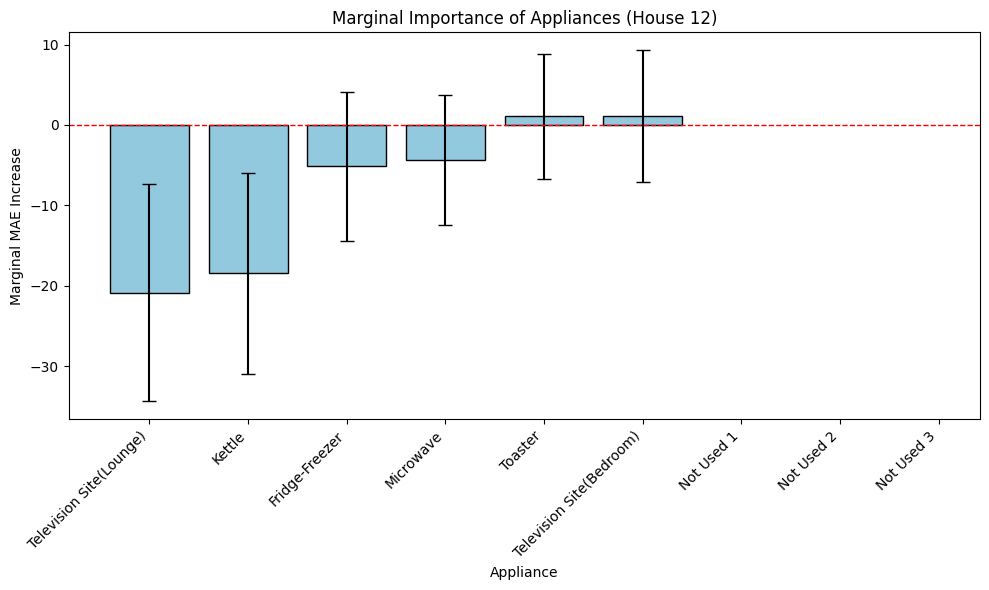

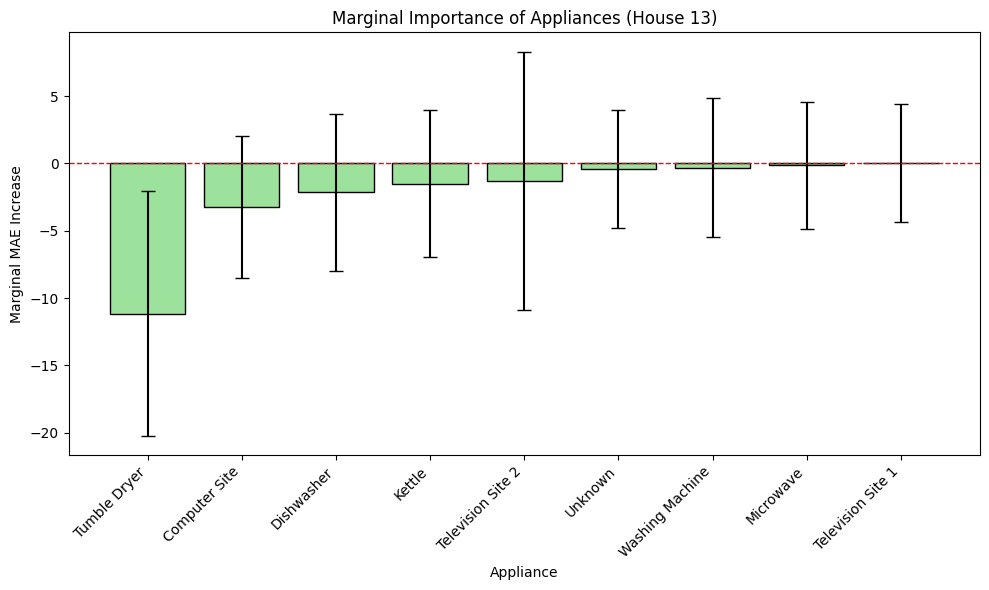

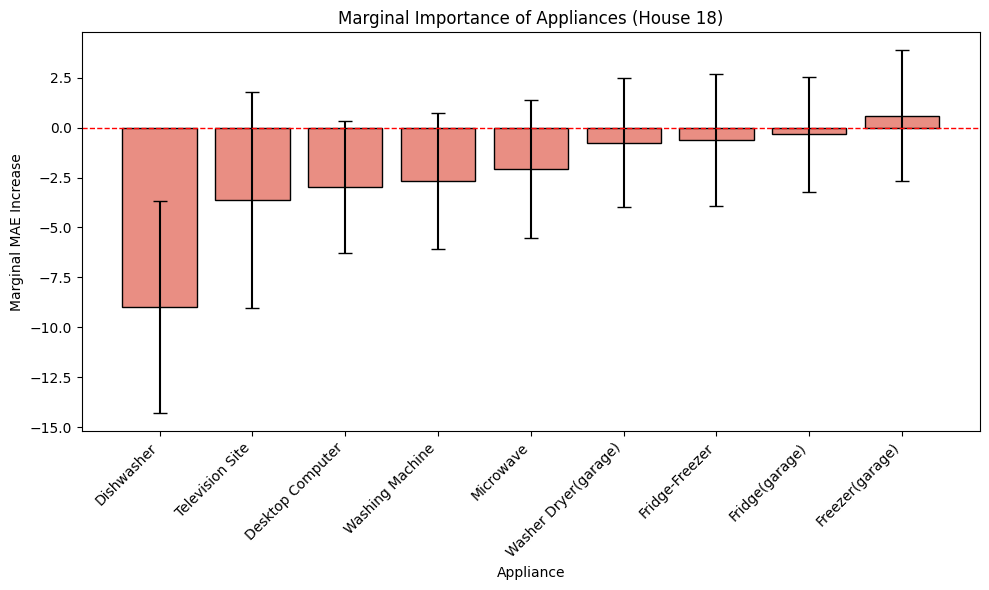

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Appliance", y="marginal_mean", data=marginal_importance_12, color="skyblue", edgecolor="black")
plt.errorbar(x=marginal_importance_12["Appliance"], y=marginal_importance_12["marginal_mean"], yerr=marginal_importance_12["marginal_std"], fmt="none", ecolor="black", capsize=5)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Marginal Importance of Appliances (House 12)")
plt.ylabel("Marginal MAE Increase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="Appliance", y="marginal_mean", data=marginal_importance_13, color="lightgreen", edgecolor="black")
plt.errorbar(x=marginal_importance_13["Appliance"], y=marginal_importance_13["marginal_mean"], yerr=marginal_importance_13["marginal_std"], fmt="none", ecolor="black", capsize=5)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Marginal Importance of Appliances (House 13)")
plt.ylabel("Marginal MAE Increase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="Appliance", y="marginal_mean", data=marginal_importance_18, color="salmon", edgecolor="black")
plt.errorbar(x=marginal_importance_18["Appliance"], y=marginal_importance_18["marginal_mean"], yerr=marginal_importance_18["marginal_std"], fmt="none", ecolor="black", capsize=5)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Marginal Importance of Appliances (House 18)")
plt.ylabel("Marginal MAE Increase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()